In [ ]:
!pip install geovoronoi

import numpy as np
from itertools import combinations
from shapely.geometry import Polygon, Point, LineString, MultiPolygon
from shapely.ops import triangulate, unary_union
import matplotlib.pyplot as plt
import geopandas as gpd
from geovoronoi import voronoi_regions_from_coords
import pandas as pd
from tabulate import tabulate


In [ ]:
def discretizar_poligono_shapely(poligono):
    contorno = LineString(poligono.exterior.coords)
    num_puntos = int(contorno.length / 0.1)
    puntos = [contorno.interpolate(distancia).coords[0] for distancia in np.linspace(0, contorno.length, num_puntos)]

    return puntos

def puntos_interior_grilla(poligono):
    max_x = max(poligono.exterior.coords, key=lambda p: p[0])[0]
    min_x = min(poligono.exterior.coords, key=lambda p: p[0])[0]
    max_y = max(poligono.exterior.coords, key=lambda p: p[1])[1]
    min_y = min(poligono.exterior.coords, key=lambda p: p[1])[1]

    x_step = (max_x - min_x) / 80
    y_step = (max_y - min_y) / 80

    puntos = []

    for x in np.arange(min_x, max_x + x_step, x_step):
        for y in np.arange(min_y, max_y + y_step, y_step):
            if Point(x, y).within(poligono):  # Comprobar si el punto está dentro del polígono
                puntos.append((x, y))

    return np.array(puntos)

def a_triangulos(poligono):
    puntos_poligono = []
    gdf_exterior_poligono = gpd.GeoDataFrame({'geometry': [poligono.buffer(-0.0000001).exterior]}).explode().reset_index()
    for geom in gdf_exterior_poligono.geometry:
        puntos_poligono += np.array(geom.coords).tolist()

    puntos_poligono = np.array([item for sublist in puntos_poligono for item in sublist]).reshape(-1, 2)
    puntos_internos = puntos_interior_grilla(poligono)
    puntos_poligono = np.vstack((puntos_poligono, puntos_internos))

    formas_poligono, puntos = voronoi_regions_from_coords(puntos_poligono, poligono)
    gdf_voronoi_poligono = gpd.GeoDataFrame({'geometry': formas_poligono}).explode().reset_index()

    triangulos_validos = []
    for geom in gdf_voronoi_poligono.geometry:
        triangulos_internos = [tri for tri in triangulate(geom) if tri.centroid.within(poligono)]
        triangulos_validos += triangulos_internos

    return triangulos_validos

def propiedades_figura(polygon):
  mesh = a_triangulos(polygon)
  poligono_completo = unary_union(mesh)
  area_total = poligono_completo.area
  centroid = poligono_completo.centroid
  centroid_array = np.array([centroid.x, centroid.y])
  return mesh, centroid_array, area_total

def mesh_compresion_poligono(mesh, punto_direccion, vector_direccion):
    centroides = np.array([[tri.centroid.x, tri.centroid.y] for tri in mesh])
    diffs = centroides - np.array(punto_direccion)
    determinantes = vector_direccion[0] * diffs[:, 1] - vector_direccion[1] * diffs[:, 0]
    mesh_compresion = [tri for tri, det in zip(mesh, determinantes) if det >= 0]
    return mesh_compresion

def propiedades_compresion(mesh_compresion):
  poligono_compresion = unary_union(mesh_compresion)
  centroid = poligono_compresion.centroid
  area = poligono_compresion.area
  centroid_array = np.array([centroid.x, centroid.y])
  return poligono_compresion, centroid_array, area

In [ ]:
def beta_funcion(fc):
  beta = np.clip(0.85-((fc-275)/68.75)*0.04, 0.65, 0.85)
  if fc > 550:
    beta = 0.65
  return beta

def coordenadas_linea_deformacion(vertices_lista, vector_direccion):
  vertices_array = np.array(vertices_lista)
  max_distancia = 0
  max_vertices = None

  for vertice1, vertice2 in combinations(vertices_array, 2):
    distancia = distancias(vertice1, vertice2, vector_direccion)
    if distancia > max_distancia:
        max_distancia = distancia
        max_vertices = (vertice1, vertice2)

  return(max_distancia, max_vertices)

def direccion_eje_neutro(theta):
  theta = np.radians(theta)
  vector_direccion = np.array([np.cos(theta), -np.sin(theta)])
  return vector_direccion

def punto_eje_compresion(theta, punto_direccion, distancia_c, max_vertice):
  distancia_a = beta*distancia_c
  magnitud_direccion = np.linalg.norm(punto_direccion)
  y = max_vertice[1] - ((distancia_a)*(punto_direccion[0]))/(magnitud_direccion)
  x = max_vertice[0] + ((distancia_a)*(punto_direccion[1]))/(magnitud_direccion)
  return np.array([x,y])

def calcular_determinante(vector_direccion, punto_referencia, coordenadas):
  x, y = coordenadas
  return vector_direccion[0] * (y - punto_referencia[1]) - vector_direccion[1] * (x - punto_referencia[0])

def distancias(punto_1, punto_2, punto_direccion):
    punto_1 = np.array(punto_1)
    punto_2 = np.array(punto_2)
    punto_direccion = np.array(punto_direccion)

    magnitud_direccion = np.linalg.norm(punto_direccion)
    if magnitud_direccion == 0:
        raise ValueError("El vector de dirección no puede ser nulo")

    diferencia = punto_1 - punto_2

    producto_cruz = diferencia[0] * punto_direccion[1] - diferencia[1] * punto_direccion[0]

    distancia = abs(producto_cruz) / magnitud_direccion
    return distancia


def propiedades_deformacion_fuerzas(mesh, vertices_lista, coordenadas_acero, as_acero, vector_direccion, centroide, c, theta):
    distancia_c = c
    a = distancia_c*beta
    acero_array = np.array(coordenadas_acero)
    centroide_array = np.array(centroide)
    vertices_sobre_centroide = []


    for vertice in vertices_lista:
      x = vertice[0]
      y = vertice[1]
      determinante= vector_direccion[0]*(y-centroide[1]) - vector_direccion[1]*(x-centroide[0])
      if determinante >= 0:
        vertices_sobre_centroide.append(vertice)

    vertices_array = np.array(vertices_sobre_centroide)

    max_distancia = 0

    for vertice in vertices_array:
        for acero in acero_array:
            distancia = distancias(vertice, acero, vector_direccion)
            if distancia > max_distancia:
                max_distancia = distancia
                min_acero = acero
                max_vertice = vertice

    punto_eje_compresion_figura = punto_eje_compresion(theta, vector_direccion, distancia_c, max_vertice)
    punto_eje_distancia_c = punto_eje_compresion(theta, vector_direccion, distancia_c, max_vertice)

    mesh_compresion = mesh_compresion_poligono(mesh, punto_eje_compresion_figura, vector_direccion)
    poligono_compresion, centroide_de_compresion_poligono, zona_de_compresion_poligono = propiedades_compresion(mesh_compresion)

    distancias_acero = []
    orden_acero = []
    sobre_compresion = []
    sobre_eje_c = []
    sobre_eje_figura = []
    tension_acero = []
    acero_a_restar = []
    phi_carga = []

    Cc = zona_de_compresion_poligono*0.85*fc
    carga_nominal = [Cc]

    brazo_x = centroide_array[0] - centroide_de_compresion_poligono[0]
    brazo_y = centroide_de_compresion_poligono[1] - centroide_array[1]

    momento_nominal_x = [Cc*brazo_y]
    momento_nominal_y = [Cc*brazo_x]

    for i, acero in enumerate(acero_array):
      distancia = distancias(max_vertice, acero, vector_direccion)
      distancias_acero.append(distancia)
      orden_acero.append(acero)

      x = acero[0]
      y = acero[1]
      determinante_eje_compresion = calcular_determinante(vector_direccion, punto_eje_compresion_figura, acero)
      determinante_eje_sobre_c = calcular_determinante(vector_direccion, punto_eje_distancia_c, acero)
      determinante_eje_centroide_figura = calcular_determinante(vector_direccion, centroide_array, acero)

      if determinante_eje_centroide_figura > 0:
        sobre_eje_figura.append(True)
      else:
        sobre_eje_figura.append(False)

      if determinante_eje_compresion > 0:
        sobre_compresion.append(True)
      else:
        sobre_compresion.append(False)

      es = (eu/distancia_c)*(distancia_c-distancia)
      fs = es*Es
      fs = np.clip(fs, -fy, fy)
      tension_acero.append(fs)

      if determinante_eje_sobre_c > 0:
        sobre_eje_c.append(True)
      else:
        sobre_eje_c.append(False)

      if np.array_equal(acero, min_acero):
        ey = fy/Es
        es = -es
        phi = 0.65 + 0.25*((es-ey)/(0.005-ey))
        phi = np.clip(phi, 0.65, 0.9)

    distancias_acero_ordenadas = np.array(list(distancias_acero))
    as_acero = np.array(list(as_acero))
    sobre_compresion = np.array(list(sobre_compresion))
    tension_acero = np.array(list(tension_acero))
    sobre_eje_c = np.array(list(sobre_eje_c))
    orden_acero_ordenado = np.array([tuple(a) for a in orden_acero])

    cantidad_elementos = len(distancias_acero_ordenadas)
    for i in range(0,cantidad_elementos,1):

      if sobre_compresion[i] == True:
        As = as_acero[i]
        Area = As*0.85*fc
        acero_a_restar.append(-Area)
        carga = as_acero[i]*tension_acero[i] - Area

      else:
        Area = 0
        acero_a_restar.append(0)
        carga = as_acero[i]*tension_acero[i] - Area

      brazo_x = centroide_array[0] - orden_acero_ordenado[i][0]
      brazo_y = orden_acero_ordenado[i][1] - centroide_array[1]

      momento_y = carga*brazo_x
      momento_x = carga*brazo_y

      carga_nominal.append(carga)
      momento_nominal_x.append(momento_x)
      momento_nominal_y.append(momento_y)


    acero_a_restar = np.array(list(acero_a_restar))
    carga_nominal = np.array(carga_nominal)
    momento_nominal_x = np.array(momento_nominal_x)
    momento_nominal_y = np.array(momento_nominal_y)
    phi_carga = np.array(phi_carga)

    return(min_acero, max_vertice, max_distancia, distancias_acero_ordenadas,
           orden_acero_ordenado, as_acero, sobre_compresion, acero_a_restar,
           tension_acero, sobre_eje_c, carga_nominal, momento_nominal_x, momento_nominal_y, poligono_compresion,
           mesh_compresion, centroide_de_compresion_poligono, phi)

In [ ]:
def generar_graficos_y_tabla(mesh, vertices, coordenadas_acero, as_acero, centroide, alpha):
    print(f"Calculando: {alpha}°")
    vector_direccion = direccion_eje_neutro(alpha)

    start = 0.6
    end = 200
    num_points = 15

    t = np.linspace(0, 1, num_points)
    t_transformed = t**0.5
    c_array = 10 ** (t_transformed * (np.log10(end) - np.log10(start)) + np.log10(start))

    c_array_invertido = c_array[::-1]

    momentos_x = []
    momentos_y = []
    carga = []
    momentos_x_phi = []
    momentos_y_phi = []
    carga_phi = []
    momento_absoluto = []
    momento_absoluto_phi_array = []
    phi_array = []

    for i, c in enumerate(c_array_invertido):
        resultados = propiedades_deformacion_fuerzas(
            mesh, vertices, coordenadas_acero,
            as_acero, vector_direccion, centroide, c, alpha
        )
        phi = resultados[16]
        p_nominal = sum(resultados[10]) / 1000

        if i == 0:
            p_nominal = p_nominal * 0.8
            compresion_limite = p_nominal

        if i == 0 or p_nominal < compresion_limite:
            m_nominal_x = (sum(resultados[11]) / (1000 * 100))
            m_nominal_y = (sum(resultados[12]) / (1000 * 100))
            m_momento_absoluto = np.sqrt(m_nominal_x**2 + m_nominal_y**2)

            p_nominal_phi = p_nominal * phi
            m_nominal_x_phi = m_nominal_x * phi
            m_nominal_y_phi = m_nominal_y * phi
            momento_absoluto_phi = np.sqrt(m_nominal_x_phi**2 + m_nominal_y_phi**2)

            phi_array.append(phi)
            momentos_x.append(m_nominal_x)
            momentos_y.append(m_nominal_y)
            momento_absoluto.append(m_momento_absoluto)
            carga.append(p_nominal)

            momentos_x_phi.append(m_nominal_x_phi)
            momentos_y_phi.append(m_nominal_y_phi)
            momento_absoluto_phi_array.append(momento_absoluto_phi)
            carga_phi.append(p_nominal_phi)

    df = pd.DataFrame({
        f'Carga ángulo {alpha}°': carga,
        'Momento en X': momentos_x,
        'Momento en Y': momentos_y,
        'Momento absoluto': momento_absoluto,
        'phi': phi_array,
        f'Carga φ ángulo {alpha}°': carga_phi,
        'Momento en X φ': momentos_x_phi,
        'Momento en Y φ': momentos_y_phi,
        'Momento absoluto φ': momento_absoluto_phi_array,
    })

    threshold = 1e-1
    df = df.apply(lambda col: col.map(lambda x: 0 if abs(x) < threshold else x))
    print(tabulate(df, headers='keys', tablefmt='plain', showindex=False))

    x_min = min(min(momentos_x), min(momentos_y), min(momento_absoluto)) + 1
    x_max = max(max(momentos_x), max(momentos_y), max(momento_absoluto)) + 1
    y_min = min(carga) + 1
    y_max = max(carga) + 1

    x_min_phi = min(min(momentos_x_phi), min(momentos_y_phi), min(momento_absoluto_phi_array))
    x_max_phi = max(max(momentos_x_phi), max(momentos_y_phi), max(momento_absoluto_phi_array))
    y_min_phi = min(carga_phi)
    y_max_phi = max(carga_phi)

    fig, axs = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)

    for ax in axs[0]:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.grid(True)

    for ax in axs[1]:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.grid(True)

    axs[0, 0].plot((momentos_x), carga, marker='o', color='blue', label='Momento_X')
    axs[0, 0].set_xlabel('Momento en X [Tonf*m]')
    axs[0, 0].set_ylabel('Carga [Tonf]')
    axs[0, 0].set_title(f'Momento en X vs Carga (ángulo {alpha}°)')
    axs[0, 0].legend()

    axs[0, 1].plot((momentos_y), carga, marker='s', color='green', label='Momento_Y')
    axs[0, 1].set_xlabel('Momento en Y [Tonf*m]')
    axs[0, 1].set_title(f'Momento en Y vs Carga (ángulo {alpha}°)')
    axs[0, 1].legend()

    axs[0, 2].plot(momento_absoluto, carga, marker='^', color='red', label='Momento absoluto')
    axs[0, 2].set_xlabel('Momento absoluto [Tonf*m]')
    axs[0, 2].set_title(f'Momento absoluto vs Carga (ángulo {alpha}°)')
    axs[0, 2].legend()

    axs[1, 0].plot((momentos_x_phi), carga_phi, marker='o', color='cyan', label='Momento_X (phi)')
    axs[1, 0].set_xlabel('Momento en X (φ) [Tonf*m]')
    axs[1, 0].set_ylabel('Carga (φ) [Tonf]')
    axs[1, 0].set_title(f'Momento en X vs Carga (con φ, ángulo {alpha}°)')
    axs[1, 0].legend()

    axs[1, 1].plot((momentos_y_phi), carga_phi, marker='s', color='lime', label='Momento_Y (phi)')
    axs[1, 1].set_xlabel('Momento_Y (φ) [Tonf*m]')
    axs[1, 1].set_title(f'Momento en Y vs Carga (con φ, ángulo {alpha}°)')
    axs[1, 1].legend()

    axs[1, 2].plot(momento_absoluto_phi_array, carga_phi, marker='^', color='magenta', label='Momento absoluto (phi)')
    axs[1, 2].set_xlabel('Momento absoluto (φ) [Tonf*m]')
    axs[1, 2].set_title(f'Momento absoluto vs Carga (con φ, ángulo {alpha}°)')
    axs[1, 2].legend()

    plt.show()

    return df

In [ ]:
def interpolacion(x1, x2, y1, y2, x):
  return y1 + ((x-x1)*(y2-y1))/(x2-x1)

def roseta_de_momentos(mesh, vertices, coordenadas_acero, as_acero, centroide, pu):

    start = 1
    end = 200
    num_points = 14

    t = np.linspace(0, 1, num_points)
    t_transformed = t**0.5
    c_array = 10 ** (t_transformed * (np.log10(end) - np.log10(start)) + np.log10(start))
    c_array_invertido = c_array[::-1]

    #listas para almacenar resultados
    pu_mn_x_array = []
    pu_mn_y_array = []
    pu_phi_array = []

    pu_mn_x_phi_array = []
    pu_mn_y_phi_array = []

    alpha_array = np.arange(0, 370, 45)

    for alpha in alpha_array:
      print(f"Calculando {alpha}°")
      vector_direccion = direccion_eje_neutro(alpha)
      momentos_x = []
      momentos_y = []
      carga = []
      momentos_x_phi = []
      momentos_y_phi = []
      carga_phi = []
      momento_absoluto = []
      momento_absoluto_phi_array = []
      phi_array = []

      for i, c in enumerate(c_array_invertido):
        resultados = propiedades_deformacion_fuerzas(
            mesh, vertices, coordenadas_acero,
            as_acero, vector_direccion, centroide, c, alpha
        )
        phi = resultados[16]
        p_nominal = sum(resultados[10]) / 1000
        if i == 0:
          p_nominal *= 0.8
          compresion_limite = p_nominal

        if i == 0 or p_nominal < compresion_limite:
            m_nominal_x = (sum(resultados[11]) / (1000 * 100))
            m_nominal_y = (sum(resultados[12]) / (1000 * 100))
            m_momento_absoluto = np.sqrt(m_nominal_x**2 + m_nominal_y**2)

            p_nominal_phi = p_nominal * phi
            m_nominal_x_phi = m_nominal_x * phi
            m_nominal_y_phi = m_nominal_y * phi
            momento_absoluto_phi = np.sqrt(m_nominal_x_phi**2 + m_nominal_y_phi**2)

            phi_array.append(phi)
            momentos_x.append(m_nominal_x)
            momentos_y.append(m_nominal_y)
            momento_absoluto.append(m_momento_absoluto)
            carga.append(p_nominal)

            momentos_x_phi.append(m_nominal_x_phi)
            momentos_y_phi.append(m_nominal_y_phi)
            momento_absoluto_phi_array.append(momento_absoluto_phi)
            carga_phi.append(p_nominal_phi)

      cantidad_elementos = len(carga)
      for i in range(0, cantidad_elementos, 1):
        if len(carga) > i + 1 and 0 < i < len(carga) and carga[i+1] < pu < carga[i]:
          pu_mn_x = interpolacion(carga[i], carga[i+1], momentos_x[i], momentos_x[i+1], pu)
          pu_mn_y = interpolacion(carga[i], carga[i+1], momentos_y[i], momentos_y[i+1], pu)
          pu_phi = interpolacion(carga[i], carga[i+1], phi_array[i], phi_array[i+1], pu)

          pu_mn_x_array.append(pu_mn_x)
          pu_mn_y_array.append(pu_mn_y)
          pu_phi_array.append(pu_phi)

          pu_mn_x_phi_array.append(pu_mn_x*pu_phi)
          pu_mn_y_phi_array.append(pu_mn_y*pu_phi)




    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    ax1.plot(pu_mn_x_array, pu_mn_y_array, marker='o', linestyle='-', color='b')
    ax1.set_title(f"Curva Mn x vs Mn y para Pu: {pu} [Tonf]", fontsize=14)
    ax1.set_xlabel("Mn X [Tonf*m]", fontsize=12)
    ax1.set_ylabel("Mn Y [Tonf*m]", fontsize=12)
    ax1.grid(True)

    ax2.plot(pu_mn_x_phi_array, pu_mn_y_phi_array, marker='s', linestyle='--', color='r')
    ax2.set_title(f"Curva (φ) Mn x vs Mn y para Pu: {pu} [Tonf] ", fontsize=14)
    ax2.set_xlabel("Mn X (φ) [Tonf*m]", fontsize=12)
    ax2.set_ylabel("Mn Y (φ) [Tonf*m]", fontsize=12)
    ax2.grid(True)

    plt.tight_layout()

    plt.show()


In [ ]:
def graficar_seccion(vertices, coordenadas_acero):

    fig, ax = plt.subplots(figsize=(6, 6))
    polygon = Polygon(vertices)
    x, y = polygon.exterior.xy
    ax.plot(x, y, 'b-', label="Polígono", linewidth=2)

    acero_x, acero_y = zip(*coordenadas_acero)
    ax.scatter(acero_x, acero_y, color='red', label="Coordenadas acero", zorder=5)

    vert_x, vert_y = zip(*vertices)
    ax.scatter(vert_x, vert_y, color='blue', label="Vértices", zorder=5)


    ax.set_title("Sección de concreto reforzado a analizar")
    ax.set_xlabel("Eje X")
    ax.set_ylabel("Eje Y")
    ax.grid(True)

    ax.legend()
    plt.show()

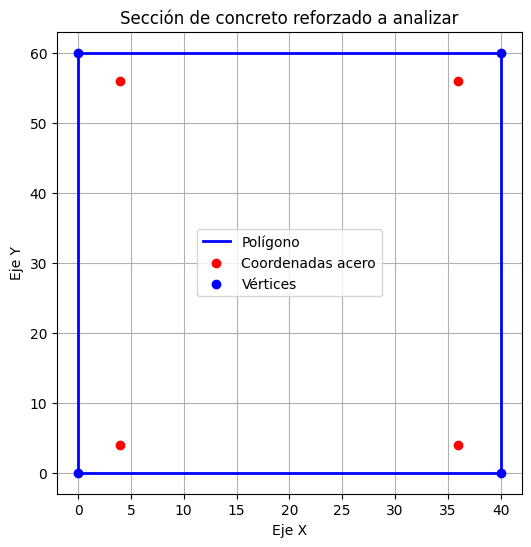

In [ ]:
#Propiedades de material
eu = 0.003
Es = 2.1*(10**6)
fc = 200
beta = beta_funcion(fc)
fy = 4200

#Todos los ejemplos hechos para fc = 200kg/cm2 y fy=4200kg/cm2

B = 40
H = 60

#rectangulo con armadura en todo su perimetro
vertices = [(0, 0), (B, 0), (B, H), (0, H)]
coordenadas_acero = [(4,4), (14.67, 4), (25.33, 4), (36, 4), (36, 17), (36, 30), (36, 43), (36, 56), (25.33, 56), (14.67, 56), (4, 56), (4, 43), (4, 30), (4, 17)]
#14 phi del 25
as_acero = [4.90625, 4.90625, 4.90625, 4.90625, 4.90625, 4.90625, 4.90625, 4.90625, 4.90625, 4.90625, 4.90625, 4.90625, 4.90625, 4.90625]



#sección T
vertices = [(22.5, 0), (37.5, 0), (37.5, 50), (60, 50), (60, 60), (0, 60), (0, 50), (22.5, 50)]
coordenadas_acero = [(25.5, 3), (34.5, 3), (57, 53), (57, 57), (34.5, 53), (34.5, 57), (25.5, 53), (25.5, 57), (3, 53), (3, 57)]
#10 phi del 28
as_acero = [6.15, 6.15, 6.15, 6.15, 6.15, 6.15, 6.15, 6.15, 6.15, 6.15]

#Seccion C
vertices = [(0,0), (60,0), (60,10), (20,10), (20,50), (60,50), (60,60), (0,60)]
coordenadas_acero = [(3,3), (17, 3), (17, 7), (3, 7), (57, 3), (57,7), (57, 53), (57, 57), (3, 53), (17, 53), (17, 57), (3, 57)]
#10 phi del 28
as_acero = [6.15, 6.15, 6.15, 6.15, 6.15, 6.15, 6.15, 6.15, 6.15, 6.15, 6.15, 6.15]

#rectangulo con armadura en todo su perimetro
vertices = [(0, 0), (B, 0), (B, H), (0, H)]
coordenadas_acero = [(4,4), (14.67, 4), (25.33, 4), (36, 4), (36, 17), (36, 30), (36, 43), (36, 56), (25.33, 56), (14.67, 56), (4, 56), (4, 43), (4, 30), (4, 17)]
#14 phi del 25
as_acero = [4.90625, 4.90625, 4.90625, 4.90625, 4.90625, 4.90625, 4.90625, 4.90625, 4.90625, 4.90625, 4.90625, 4.90625, 4.90625, 4.90625]

#rectangulo
B = 40
H = 60
r = 4
vertices = [(0, 0), (B, 0), (B, H), (0, H)]
coordenadas_acero = [(r, r), (B-r, r), (B-r, H-r), (r, H-r)]
#4 phi del 28
as_acero = [6.15, 6.15, 6.15, 6.15]

#procesamiento de figura
figura = Polygon(shell=vertices)
puntos_discretizados = discretizar_poligono_shapely(figura)
mesh_figura, centroide_figura, area_figura = propiedades_figura(figura)
graficar_seccion(vertices, coordenadas_acero)

Calculando: 120°
  Carga ángulo 120°    Momento en X    Momento en Y    Momento absoluto       phi    Carga φ ángulo 120°    Momento en X φ    Momento en Y φ    Momento absoluto φ
          405.71           0               0                   0         0.65                  263.712            0                 0                     0
          339.898        -23.8328        -17.4053             29.5118    0.65                  220.934          -15.4913          -11.3135               19.1827
          198.099        -29.9003        -23.2961             37.9043    0.65                  128.764          -19.4352          -15.1425               24.6378
           86.0115       -27.6781        -19.9807             34.1366    0.783291               67.372          -21.68            -15.6507               26.7389
            1.72512      -22.8752        -15.574              27.6735    0.9                     1.55261        -20.5877          -14.0166               24.9062
          -30.2482  

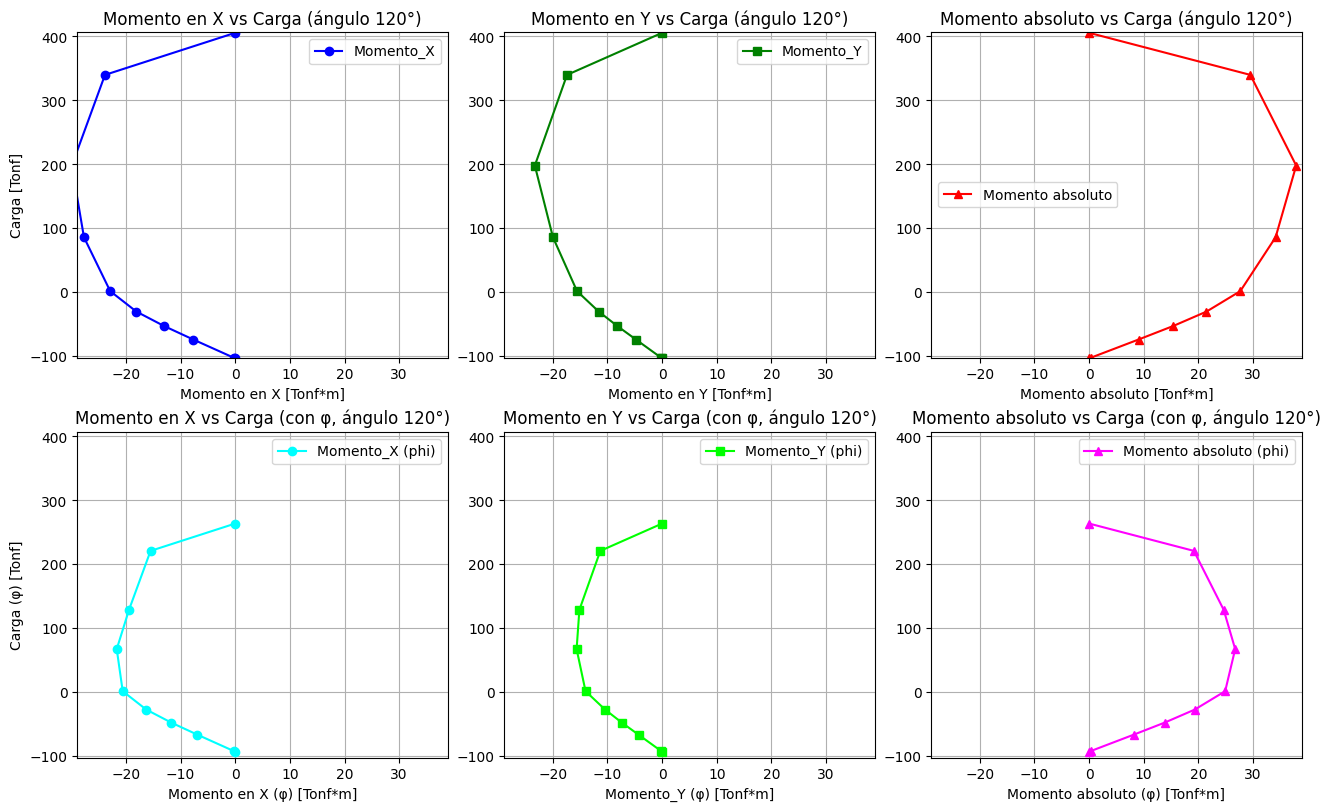

In [ ]:
#Ángulo a analizar
alpha = 120
df_resultado = generar_graficos_y_tabla(mesh_figura, vertices, coordenadas_acero, as_acero, centroide_figura, alpha)

Calculando 0°
Calculando 45°
Calculando 90°
Calculando 135°
Calculando 180°
Calculando 225°
Calculando 270°
Calculando 315°
Calculando 360°


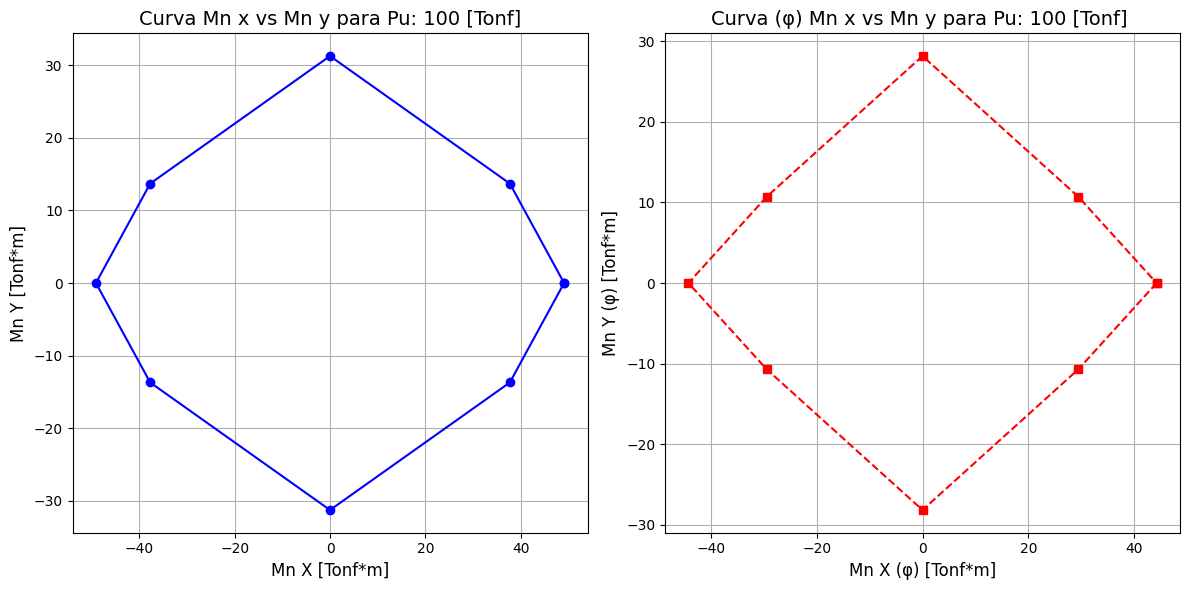

In [ ]:
#Carga mayorada Pu a analizar
pu = 100
roseta_de_momentos(mesh_figura, vertices, coordenadas_acero, as_acero, centroide_figura, pu)